# HYG: Building the Premium/Discount Evidence

**What this notebook shows.** Every step from raw data to a defensible half-life
estimate for one fund — iShares iBoxx $ High Yield Corporate Bond ETF — with the
checks that decide whether each number means anything.

HYG is the pilot fund. The build order is deliberate: take one fund end to end
before adding the other seven, because every data-quality problem shows up on the
first fund and fixing it once is far cheaper than fixing it eight times.

**The question.** When HYG's market price drifts away from its net asset value,
how fast does the gap close? And — the part that makes this research rather than
description — is that speed related to how hard the underlying bonds are to trade?

In [1]:
import sys, warnings
from pathlib import Path

# Run from anywhere inside the repo.
ROOT = Path.cwd()
while not (ROOT / "configs" / "universe.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.config import load_universe
from src.data.loaders import load_prices, load_nav_file
from src.data.align import align_price_nav
from src.data.quality import check_quality
from src.analysis.premium import add_premium, describe_premium
from src.analysis.reversion import (
    estimate_reversion, fit_ar1, half_life_from_b,
    simulate_ou, simulate_ar1, half_life_to_kappa, Resolution,
)
from src.viz.style import (
    use_house_style, annotate, PREMIUM, DISCOUNT, NEUTRAL,
    SERIES, INK, INK_SECONDARY, INK_MUTED, GRID, CRITICAL, GOOD,
)

use_house_style()
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 120)

universe = load_universe()
FUND = universe["HYG"]
print(f"{FUND.ticker} — {FUND.name}")
print(f"sleeve={FUND.sleeve}  issuer={FUND.issuer}  window={universe.start} to {universe.end_or_today}")

HYG — iShares iBoxx $ High Yield Corporate Bond ETF
sleeve=credit_hy  issuer=ishares  window=2018-01-01 to 2026-09-12


---
## 1. The two ingredients

The whole project rests on comparing two numbers that are measured completely
differently.

| | Market price | NAV |
|---|---|---|
| What it is | What HYG actually traded at, 4pm | What the fund says a share is worth |
| Set by | Continuous two-sided auction | Bid-side dealer marks on underlying bonds |
| Source | Yahoo Finance (automated) | iShares' published file (downloaded by hand) |

That difference in *how they are formed* is the whole subject. NAV is an
estimate built from instruments that may not have traded today; price is a live
market. Neither is "the truth."

In [2]:
prices = load_prices(FUND.ticker, universe.start, universe.end_or_today)
nav = load_nav_file(ROOT / "data" / "raw" / "nav" / "HYG.xls")

print(f"prices : {len(prices):>5,} rows   {prices.index.min():%Y-%m-%d} to {prices.index.max():%Y-%m-%d}")
print(f"nav    : {len(nav):>5,} rows   {nav.index.min():%Y-%m-%d} to {nav.index.max():%Y-%m-%d}")
print()
print("The NAV file reaches back to HYG's 2007 inception — far more than the")
print("2018 window needs. The surplus is filtered at alignment, not discarded.")
prices.head()

prices : 2,185 rows   2018-01-02 to 2026-09-11
nav    : 4,893 rows   2007-04-04 to 2026-09-11

The NAV file reaches back to HYG's 2007 inception — far more than the
2018 window needs. The surplus is filtered at alignment, not discarded.


Price,open,high,low,close,adj_close,volume
date,,,,,,
2018-01-02,87.300003,87.360001,87.250000,87.339996,54.979595,7223500
2018-01-03,87.339996,87.779999,87.339996,87.760002,55.243980,20557100
2018-01-04,87.820000,87.989998,87.769997,87.910004,55.338425,13610900
2018-01-05,87.970001,88.010002,87.879997,87.970001,55.376171,9851600
2018-01-08,87.959999,88.029999,87.860001,87.900002,55.332096,9804000


### 1a. The adjustment trap

The single most consequential rule in ingestion: **prices must be unadjusted.**

NAV as published is not dividend-adjusted. Yahoo offers a dividend-adjusted
series that looks equally plausible. Pair the two and you manufacture a drift
that grows with every distribution — and it fails *silently*, because a frame
from `auto_adjust=True` still has a column called `Close`.

The plot below is why this matters more for HYG than almost any other fund: it
is a high-yield bond fund, so it distributes constantly.

findfont: Failed to find font weight semibold, now using 700.


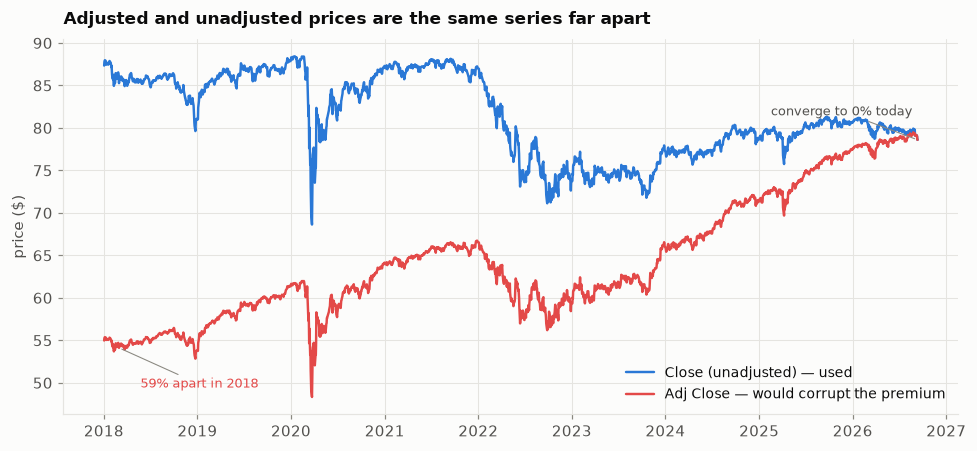

Using Adj Close against NAV would show a 5,886 bp phantom discount in 2018,
decaying monotonically to zero — swamping real premiums that live in tens of bps.


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(prices.index, prices["close"], color=PREMIUM, label="Close (unadjusted) — used")
ax.plot(prices.index, prices["adj_close"], color=DISCOUNT, label="Adj Close — would corrupt the premium")

gap_start = prices["close"].iloc[0] / prices["adj_close"].iloc[0] - 1
annotate(ax, prices.index[40], prices["adj_close"].iloc[40],
         f"{gap_start:.0%} apart in 2018", dx=14, dy=-26, color=DISCOUNT)
annotate(ax, prices.index[-1], prices["close"].iloc[-1],
         "converge to 0% today", dx=-96, dy=16)

ax.set_title("Adjusted and unadjusted prices are the same series far apart")
ax.set_ylabel("price ($)")
ax.legend(loc="lower right")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

drift_bps = (prices["close"] / prices["adj_close"] - 1).iloc[0] * 1e4
print(f"Using Adj Close against NAV would show a {drift_bps:,.0f} bp phantom discount in 2018,")
print(f"decaying monotonically to zero — swamping real premiums that live in tens of bps.")

---
## 2. Alignment: what gets dropped, and why nothing gets filled

Price and NAV must refer to the same date. Where either is missing, the row is
**dropped — never forward-filled.**

This is not fussiness. Carry Monday's NAV into a missing Tuesday and you create
a fake gap on Tuesday (price moved, NAV didn't) and a fake snap-back on Wednesday
when the real NAV arrives. That is precisely the pattern the estimator is built
to detect. You would be measuring your own data-filling and calling it arbitrage.

In [4]:
frame, align_report = align_price_nav(
    prices, nav, ticker=FUND.ticker,
    start=universe.start, end=universe.end_or_today,
)
print(align_report.summary())
print()
if align_report.nav_only:
    print("Dropped — NAV published with no corresponding US price:")
    for d in align_report.nav_only:
        print(f"   {d:%Y-%m-%d}  ({d:%A})")
    print()
    print("Both are market holidays. iShares struck a NAV; no trade existed to compare it to.")

HYG: 2185 aligned rows (2185 price, 2187 nav); dropped 0 price-only, 2 nav-only, 0 incomplete

Dropped — NAV published with no corresponding US price:
   2024-03-29  (Friday)
   2024-03-31  (Sunday)

Both are market holidays. iShares struck a NAV; no trade existed to compare it to.


---
## 3. The premium series

```
premium = price / NAV − 1        reported in basis points (1bp = 0.01%)
```

A **ratio**, not a difference — a 10-cent gap means something entirely different
on a \$40 fund than a \$400 one, and the whole point is comparing funds.

Positive is a premium (price above NAV), negative a discount.

In [5]:
frame = add_premium(frame)
stats = describe_premium(frame, ticker=FUND.ticker)

print(f"  observations   {stats.n:>10,}")
print(f"  mean           {stats.mean_bps:>+10.2f} bps")
print(f"  median         {stats.median_bps:>+10.2f} bps")
print(f"  std dev        {stats.sd_bps:>10.2f} bps")
print(f"  min / max      {stats.min_bps:>+10.1f} / {stats.max_bps:+.1f} bps")
print(f"  days at premium{stats.frac_premium:>10.1%}")
print(f"  p(mean = 0)    {stats.p_value:>10.2g}")

  observations        2,185
  mean               +17.97 bps
  median             +16.60 bps
  std dev             30.74 bps
  min / max          -166.2 / +458.7 bps
  days at premium     82.0%
  p(mean = 0)      1.4e-141


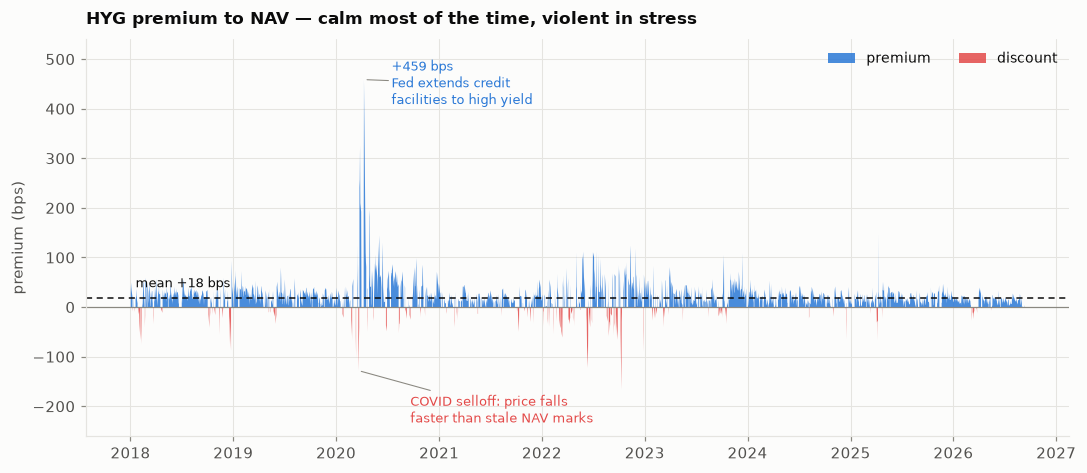

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.4))
p = frame["premium_bps"]

ax.fill_between(p.index, 0, p.where(p >= 0), color=PREMIUM, alpha=0.85, lw=0, label="premium")
ax.fill_between(p.index, 0, p.where(p < 0), color=DISCOUNT, alpha=0.85, lw=0, label="discount")
ax.axhline(0, color=INK_MUTED, lw=0.8)
ax.axhline(stats.mean_bps, color=INK, lw=1.0, ls=(0, (4, 3)))

ax.text(p.index[12], stats.mean_bps + 22, f"mean {stats.mean_bps:+.0f} bps",
        fontsize=8.5, color=INK)

peak = p.idxmax()
annotate(ax, peak, p.loc[peak], f"{p.loc[peak]:+.0f} bps\nFed extends credit\nfacilities to high yield",
         dx=18, dy=-16, color=PREMIUM)
trough = p.loc["2020-03-01":"2020-03-31"].idxmin()
annotate(ax, trough, p.loc[trough], "COVID selloff: price falls\nfaster than stale NAV marks",
         dx=34, dy=-34, color=DISCOUNT)

# Explicit limits leave room for the lower annotation instead of letting it
# collide with the date axis.
ax.set_ylim(-260, 540)

ax.set_title("HYG premium to NAV — calm most of the time, violent in stress")
ax.set_ylabel("premium (bps)")
ax.legend(loc="upper right", ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

**Read the March–April 2020 sequence carefully — it is the most informative thing
in the series.**

First a deep **discount**: markets crashed, HYG repriced instantly in a live
two-sided market, while NAV was struck from dealer marks on bonds that had barely
traded. The ETF was arguably the *better* price; the discount was a statement
about NAV, not about HYG.

Then, on 9 April 2020, the largest **premium** in the sample. That is the day the
Fed extended its credit facilities to include high-yield. HYG repriced upward
within minutes; NAV marks lagged by a day.

Neither episode is a data error. This is what the project exists to measure.

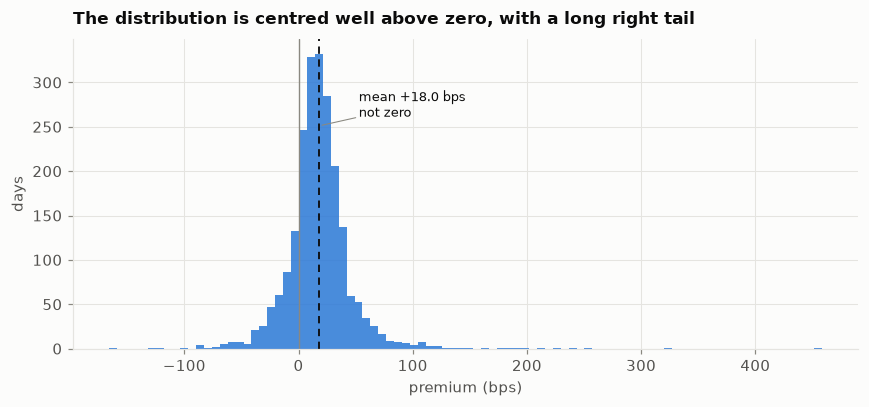

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))

ax.hist(p, bins=90, color=PREMIUM, alpha=0.85)
ax.axvline(0, color=INK_MUTED, lw=0.9)
ax.axvline(stats.mean_bps, color=INK, lw=1.2, ls=(0, (4, 3)))
annotate(ax, stats.mean_bps, ax.get_ylim()[1] * 0.72,
         f"mean {stats.mean_bps:+.1f} bps\nnot zero", dx=26, dy=6, color=INK)

ax.set_title("The distribution is centred well above zero, with a long right tail")
ax.set_xlabel("premium (bps)"); ax.set_ylabel("days")
plt.tight_layout(); plt.show()

---
## 4. Is that +18 bps mean a bug?

A persistently non-zero mean premium is **far more likely to be a data error than
a genuine arbitrage the whole market has ignored.** So it gets treated as an
alarm and investigated before it is believed.

Two tests, each targeting a specific way the pipeline could be wrong.

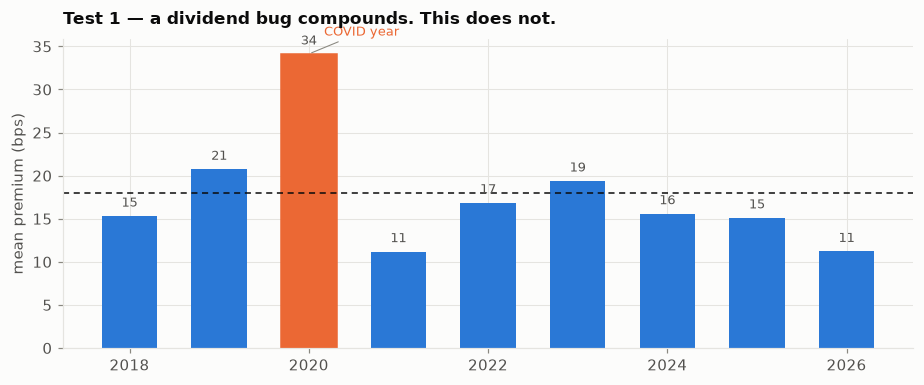

first year 15.3 bps   last year 11.2 bps
A dividend-adjustment error accumulates with every distribution, so it would
grow year on year. The level is flat — that hypothesis is dead.


In [8]:
yearly = frame.groupby(frame.index.year)["premium_bps"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8.5, 3.6))
bars = ax.bar(yearly.index, yearly["mean"], color=PREMIUM, width=0.62)
bars[list(yearly.index).index(2020)].set_color(SERIES[1])

ax.axhline(stats.mean_bps, color=INK, lw=1.0, ls=(0, (4, 3)))
for yr, v in yearly["mean"].items():
    ax.text(yr, v + 1.1, f"{v:.0f}", ha="center", fontsize=8.5, color=INK_SECONDARY)
annotate(ax, 2020, yearly.loc[2020, "mean"], "COVID year", dx=10, dy=12, color=SERIES[1])

ax.set_title("Test 1 — a dividend bug compounds. This does not.")
ax.set_ylabel("mean premium (bps)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

first, last = yearly["mean"].iloc[0], yearly["mean"].iloc[-1]
print(f"first year {first:.1f} bps   last year {last:.1f} bps")
print("A dividend-adjustment error accumulates with every distribution, so it would")
print("grow year on year. The level is flat — that hypothesis is dead.")

In [9]:
# Test 2: the ex-dividend column that came free in the iShares export.
import re, xml.etree.ElementTree as ET
from src.data.loaders import _ssml_row_values, _BARE_AMP

NS = {"ss": "urn:schemas-microsoft-com:office:spreadsheet"}
SS = "{urn:schemas-microsoft-com:office:spreadsheet}"
raw = (ROOT / "data" / "raw" / "nav" / "HYG.xls").read_text(encoding="utf-8", errors="replace")
root = ET.fromstring(_BARE_AMP.sub("&amp;", raw))
sheet = [w for w in root.findall("ss:Worksheet", NS) if w.get(SS + "Name") == "Historical"][0]
rows = [_ssml_row_values(r) for r in sheet.findall(".//ss:Row", NS)]
hist = pd.DataFrame([r for r in rows[1:] if len(r) >= 4 and r[0]], columns=rows[0])
hist["date"] = pd.to_datetime(hist["As Of"], format="mixed")
hist["exdiv"] = pd.to_numeric(hist["Ex-Dividends"].replace("--", np.nan), errors="coerce")

exdiv_dates = set(hist.loc[hist["exdiv"].notna(), "date"])
is_ex = frame.index.isin(exdiv_dates)
typical_bps = hist["exdiv"].mean() / frame["nav"].mean() * 1e4

print(f"  ex-dividend days   {p[is_ex].mean():+.2f} bps   (n={is_ex.sum()})")
print(f"  all other days     {p[~is_ex].mean():+.2f} bps   (n={(~is_ex).sum()})")
print(f"  difference         {p[is_ex].mean() - p[~is_ex].mean():+.2f} bps")
print()
print(f"A price/NAV dividend convention mismatch would separate these by roughly")
print(f"the distribution size, ~{typical_bps:.0f} bps. It does not. That hypothesis is dead too.")

  ex-dividend days   +19.21 bps   (n=104)
  all other days     +17.90 bps   (n=2081)
  difference         +1.31 bps

A price/NAV dividend convention mismatch would separate these by roughly
the distribution size, ~55 bps. It does not. That hypothesis is dead too.


**Conclusion: the +18 bps level is real, and it is microstructure.**

Bond ETF NAV is struck from **bid-side** evaluated pricing on instruments that
may not have traded that day, while HYG itself trades around **mid**. The fund
systematically prints above NAV by roughly half the underlying bid-ask spread.

This is also the answer to the standard interview question *"why isn't the bond
ETF discount free money?"* — a large part of the deviation is a statement about
how NAV is constructed, not about the ETF being mispriced.

---
## 5. Quality checks — flag, never delete

Two checks: NAV barely moving while price moves (stale feed or a closed
underlying market), and premiums outside a plausible band.

Both produce **counts and dates**. Neither removes a row. An outlier filter
applied silently is indistinguishable from cherry-picking, and here the extremes
are the most economically meaningful data in the sample — deleting March 2020
would remove the observations that actually test the hypothesis.

In [10]:
frame, quality = check_quality(frame, ticker=FUND.ticker, band_bps=FUND.outlier_band_bps)
print(quality.summary())
print()
print(f"rows in : {align_report.n_aligned:,}")
print(f"rows out: {len(frame):,}   <- unchanged by design")
print()
if quality.stale_dates:
    print("Stale-NAV flags (retained, not removed):")
    for d in quality.stale_dates[:8]:
        print(f"   {d:%Y-%m-%d}  premium {frame.loc[d, 'premium_bps']:+7.1f} bps")

HYG: n=2185 stale_nav=11 (0.50%) extreme>800bps=0 (0.00%) longest_nav_run=2

rows in : 2,185
rows out: 2,185   <- unchanged by design

Stale-NAV flags (retained, not removed):
   2018-02-27  premium   +17.5 bps
   2018-03-26  premium   +31.6 bps
   2018-04-03  premium   +40.6 bps
   2020-05-11  premium   +28.8 bps
   2022-06-14  premium   -56.9 bps
   2022-12-14  premium    +3.8 bps
   2023-02-07  premium   +31.6 bps
   2023-12-01  premium   +71.4 bps


---
## 6. The model

Model today's premium as a fraction of yesterday's, plus noise:

$$\text{premium}_{t+1} = a + b \cdot \text{premium}_t + \varepsilon_{t+1}$$

Everything hangs on $b$:

| $b$ | meaning |
|---|---|
| 0 | no memory — today says nothing about tomorrow |
| 0.5 | half the gap survives one day |
| 0.95 | gaps persist for weeks |
| 1.0 | gaps never close (random walk) |

$$\text{half-life} = \frac{\ln 2}{-\ln b} \quad \text{“days to close half the gap”}$$

findfont: Failed to find font weight semibold, now using 700.


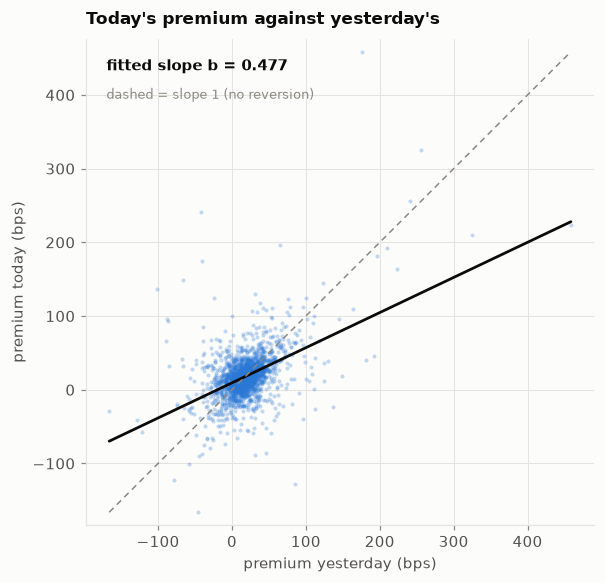

The fitted line is much flatter than the 45° dashed line.
b = 0.4767 means roughly 48% of today's gap survives to tomorrow.


In [11]:
lagged, current = p.values[:-1], p.values[1:]
fit = fit_ar1(p)

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.scatter(lagged, current, s=7, color=PREMIUM, alpha=0.28, lw=0)

grid = np.linspace(lagged.min(), lagged.max(), 100)
ax.plot(grid, fit.a + fit.b * grid, color=INK, lw=1.8)
ax.plot(grid, grid, color=INK_MUTED, lw=1.0, ls=(0, (4, 3)))

ax.text(0.04, 0.96, f"fitted slope b = {fit.b:.3f}", transform=ax.transAxes,
        fontsize=10, color=INK, va="top", fontweight="semibold")
ax.text(0.04, 0.90, "dashed = slope 1 (no reversion)", transform=ax.transAxes,
        fontsize=8.5, color=INK_MUTED, va="top")

ax.set_title("Today's premium against yesterday's")
ax.set_xlabel("premium yesterday (bps)"); ax.set_ylabel("premium today (bps)")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout(); plt.show()

print(f"The fitted line is much flatter than the 45° dashed line.")
print(f"b = {fit.b:.4f} means roughly {fit.b:.0%} of today's gap survives to tomorrow.")

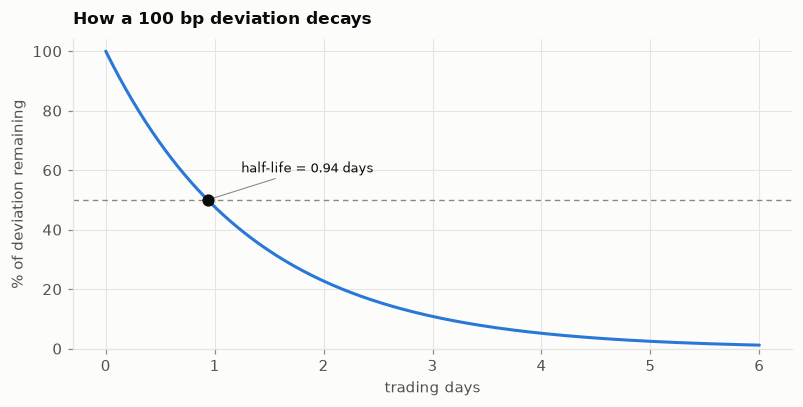

In [12]:
hl = half_life_from_b(fit.b)
days = np.linspace(0, 6, 200)

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.plot(days, 100 * fit.b**days, color=PREMIUM, lw=2)
ax.axhline(50, color=INK_MUTED, lw=0.9, ls=(0, (4, 3)))
ax.plot([hl], [50], "o", color=INK, ms=7, zorder=5)
annotate(ax, hl, 50, f"half-life = {hl:.2f} days", dx=22, dy=18, color=INK)

ax.set_title("How a 100 bp deviation decays")
ax.set_xlabel("trading days"); ax.set_ylabel("% of deviation remaining")
ax.set_ylim(0, 104)
plt.tight_layout(); plt.show()

---
## 7. Does the number mean anything?

This is the step that separates a measurement from a plausible-looking artefact.

Daily close-to-close data can only resolve half-lives inside a window, and both
ends fail for opposite reasons. Crucially, **the estimator does not go quiet when
it fails — it returns confident nonsense.** So two tests run before any half-life
is believed.

In [13]:
N = len(p)
demo = {
    "true random walk":        simulate_ar1(1.0, N, seed=1),
    "OU, true half-life 3d":   simulate_ou(half_life_to_kappa(3.0), N, seed=1),
    "OU, true half-life 0.05d": simulate_ou(half_life_to_kappa(0.05), N, seed=1),
    "pure white noise":        np.random.default_rng(0).standard_normal(N),
    "bid-ask bounce":          simulate_ar1(-0.4, N, seed=1),
}

print(f"{'series':<26} {'naive half-life':>16}   {'guarded verdict':<28}")
print("-" * 74)
for name, path in demo.items():
    naive = half_life_from_b(fit_ar1(path).b)
    r = estimate_reversion(path, ticker=name)
    naive_s = f"{naive:,.1f} d" if np.isfinite(naive) else "n/a"
    print(f"{name:<26} {naive_s:>16}   {r.display:<28}")

series                      naive half-life   guarded verdict             
--------------------------------------------------------------------------
true random walk                    292.7 d   n/a (unit_root)             
OU, true half-life 3d                 3.0 d   3.00 d                      
OU, true half-life 0.05d              0.1 d   < 0.23 d (censored)         
pure white noise                        n/a   < 0.20 d (censored)         
bid-ask bounce                          n/a   n/a (oscillatory)           


Read the first row carefully. A **true random walk** — a series with no reversion
whatsoever — produces a confident three-figure half-life when estimated naively.
Worse, that number is arbitrary: it scales with sample size (135 days at n=500,
293 at n=2,185, 16,700 at n=50,000). It is a function of how much data you
happened to have, not of the process.

The third and fourth rows are the case behind **your intraday question**. If a
deviation opens, closes, and reopens within one session, daily data cannot see
it — a 10-minute and a 50-minute half-life both give $b \approx 0$. The naive
estimator returns ~0.2 days, which looks like a measurement and is pure sampling
noise. The guard refuses to report it and gives a censored upper bound instead.

In [14]:
result = estimate_reversion(p, ticker=FUND.ticker)

print("=" * 66)
print(f"  {FUND.ticker} — {frame.index.min():%Y-%m-%d} to {frame.index.max():%Y-%m-%d}")
print("=" * 66)
print(f"  observations      {result.n:>12,}")
print(f"  AR(1) b           {result.fit.b:>12.4f}   (robust se {result.fit.b_se:.4f})")
print(f"  ADF p-value       {result.adf_pvalue:>12.2e}   -> not a random walk")
print(f"  p(b = 0)          {result.fit.b_pvalue:>12.2e}   -> not white noise")
print(f"  long-run level    {result.fit.long_run:>+12.2f} bps")
print("-" * 66)
print(f"  RESOLUTION        {result.resolution.value:>12}")
print(f"  HALF-LIFE         {result.display:>12}")
print("=" * 66)
print()
print(result.reason)

  HYG — 2018-01-02 to 2026-09-11
  observations             2,184
  AR(1) b                 0.4767   (robust se 0.0505)
  ADF p-value           2.26e-10   -> not a random walk
  p(b = 0)              3.45e-21   -> not white noise
  long-run level          +17.94 bps
------------------------------------------------------------------
  RESOLUTION          identified
  HALF-LIFE               0.94 d

Distinguishable from both a random walk (ADF p=2.26e-10) and white noise (p(b=0)=3.45e-21).


---
## 8. Where this leaves us

**The result.** When HYG's price diverges from NAV, about half the gap closes in
**under one trading day**. The deviation is real, it survives both guards, and it
decays toward a persistent +18 bp level rather than toward zero.

**The honest caveat, stated before anyone asks.** A half-life of ~0.94 days sits
uncomfortably close to the one-day sampling interval. It passed the guards, but a
meaningful share of the reversion is happening *intraday*, where close-to-close
data cannot follow it. The estimate is best read as "fast, and near the limit of
what daily data resolves" rather than as a precise 0.94.

**What is still missing.** A point estimate without an interval cannot support the
claim this project is actually for. The headline is a *ranking* — high-yield
credit reverts more slowly than large-cap equity — and a ranking only holds if
the intervals don't overlap. Next: a stationary block bootstrap, with a
delta-method cross-check.

Then the remaining seven funds, and the cross-section that is the real result.